Intended to determine if wind and pressure changes at 850 hPa makes more sense than the h850

In [30]:
reset

Once deleted, variables cannot be recovered. Proceed (y/[n])?  y


In [ ]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import xarray as xr
import cf_xarray as cf
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

In [ ]:
def windSpd(u,v):
   windSpd=np.sqrt(u**2 + v**2)
   return windSpd

# LOAD DATA

In [3]:
### +++ DATA PATHS +++ ###

# product keys
keys=['obs','flor']
obs_prods=['merra2']
flor_runs=['ctrl','hicam','hitopo']
flor_simNames=['ctrl','cam','hitopo']

# store file paths in dictionary
dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_heat/figs'
files={ 'obs'  : { 'merra2' : {} },
        'flor' : { 'ctrl'   : {},
                   'hicam'  : {}, 
                   'hitopo' : {} }
      }

for key in ['obs']:
    for i,run in enumerate(obs_prods):
        files[key][run]['u850'] = f'{dpath0}/obs_data/merra2/merra2.U850.1980-2022.monthly.nc' 
        files[key][run]['v850'] = f'{dpath0}/obs_data/merra2/merra2.V850.1980-2022.monthly.nc' 
        files[key][run]['h850'] = f'{dpath0}/obs_data/merra2/merra2.H850.1980-2022.monthly.nc' 

for key in ['flor']:
    for i,run in enumerate(flor_runs):
        simName=flor_simNames[i]
        for fvarn in ['u850','v850','h850']: 
            files[key][run][fvarn] = f'{dpath0}/FLOR/{run}/pi/flor.{simName}.{fvarn}.monthly.nc' 

for key in ['topo']:
    files[key] = {}
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [4]:
### +++ ORGANIZE DATA +++ ###

# time bounds
n_years=50
n_keep_days=-1 * (n_years * 365) # number of time steps to keep in days
n_keep_mons=-1 * (n_years * 12)  # number of time steps to keep in months

# initialize dictionaries
dat = { 'obs'  : { 'merra2' : {} },
        'flor' : { 'ctrl'   : {},
                   'hicam'  : {}, 
                   'hitopo' : {} }
      }

print('Working on...')
for key in ['obs']:
    varns=['u850','v850','h850']
    print(f'{key}')
    for run in obs_prods:
        for i,ovarn in enumerate(['U','V','H']):
            varn=varns[i]
            ds = xr.open_dataset(files[key][run][varn])[ovarn]
            ds_flip = lonFlip(ds) #longitude_flip(ds) # switch lons from -180:180 to 0:360
            dat[key][run][varn] = ds_flip
            del ds
            del ds_flip
        # calculate wind speed from components
        for varn in ['spd']:
            dat[key][run][varn] = windSpd(dat[key][run]['u850'],dat[key][run]['v850'])
        # calculate h850 zonal anomalies
        # !!!! not sure if this is still how I want to do calculate this...
        for varn in ['h850a']:
            dat[key][run][varn] = dat[key][run]['h850']-dat[key][run]['h850'].mean(dim='lon')

for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        for i,varn in enumerate(['u850','v850','h850']):
            ds = xr.open_dataset(files[key][run][varn])[varn][n_keep_mons:,:,:] # keep only last 50 years 
            if varn in ['u850','v850','h850']:
                ds = ds.rename({'grid_xt':'lon','grid_yt':'lat'}) # update coordinate names to match merra2
            dat[key][run][varn] = ds
            del ds
        # calculate wind speed from components
        for varn in ['spd']:
            dat[key][run][varn] = windSpd(dat[key][run]['u850'],dat[key][run]['v850'])
        # calculate h850 zonal anomalies
        for varn in ['h850a']:
            dat[key][run][varn] = dat[key][run]['h850']-dat[key][run]['h850'].mean(dim='lon')
print('Done.')

topo = {}
print('Loading surface height data.')
for key in ['topo']:
    for case in ['etopo']:
        ds = xr.open_dataset(files[key][case]).ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
        topo[case] = ds.where(ds>0, np.nan)
        del ds
    for case in ['ctrl', 'hicam', 'hitopo']:
        ds = xr.open_dataset(files[key][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        topo[case] = ds.where(ds>0, np.nan)
        del ds
print('Done.')

Working on...
obs
flor
Done.
Loading surface height data.
Done.


In [5]:
### +++ CALCULATE TIME-MEANS +++ ###
season='JAS'
mons=[7,8,9]
varns=['u850','v850','spd','h850','h850a']

jas_mean = { 'obs' : { 'merra2':{} },
             'flor': { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
ann_jas_mean = { 'obs' : { 'merra2':{} },
                 'flor': { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }

print('Calculating seasonal means for...')
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        for varn in varns:
            # seasonal mean for whole timeseries
            custom_seasons = xr.where(dat[key][run][varn]['time'].dt.month.isin(mons), season, 'Other')
            jas_mean[key][run][varn] = dat[key][run][varn].groupby(custom_seasons).mean('time').rename({'month':'season'}).sel(season=season)
            # seasonal mean by year
            ann_jas_mean[key][run][varn] = dat[key][run][varn].sel(time=dat[key][run][varn]['time'].dt.month.isin(mons)).groupby('time.year').mean(dim='time')
      
for key in ['flor']:
    print(f'{key}')
    for run in flor_runs:
        for varn in varns:
            # seasonal mean for whole timeseries
            custom_seasons = xr.where(dat[key][run][varn]['time'].dt.month.isin(mons), season, 'Other')
            jas_mean[key][run][varn] = dat[key][run][varn].groupby(custom_seasons).mean('time').rename({'month':'season'}).sel(season=season)
            # seasonal mean by year
            ann_jas_mean[key][run][varn] = dat[key][run][varn].sel(time=dat[key][run][varn]['time'].dt.month.isin(mons)).groupby('time.year').mean(dim='time')

print('Done.')

Calculating seasonal means for...
obs
flor
Done.


In [1]:
### +++ COMPARING ALL MODEL RUNS TO OBS. +++ ###

## initialize dictionaries
# for re-gridded obs data
jas_mean_regrid = { 'obs_flor' : {} }
ann_jas_mean_regrid = { 'obs_flor' : {} }
# for significance testing results
obs_diff      = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
obs_diff_mask = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }
obs_ptvals    = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} } }

# First, need to put obs data on same grid as model output
regrid_keys = ['obs_flor']

print('Re-gridding obs.')
for i,key in enumerate(['flor']):
    lats=dat[key]['ctrl']['spd'].lat
    lons=dat[key]['ctrl']['spd'].lon
    regrid_key=regrid_keys[i]
    for varn in varns:
        # interpolate obs to CM2.5-FLOR grid
        jas_mean_regrid[regrid_key][varn] = jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
        ann_jas_mean_regrid[regrid_key][varn] = ann_jas_mean['obs']['merra2'][varn].interp(lat=lats, lon=lons, method='linear')
print('Done.\n')

# Determine statistical significance of model-obs differences based on students t-test
print('Significance testing for:')
for key in obs_diff.keys():
    print(f'{key}')
    for run in flor_runs:
        print(f'...{run}')
        for varn in varns:
            #obs_diff[key][run][varn] = jas_mean_regrid['obs_flor'][varn] - jas_mean[key][run][varn]
            
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean_regrid['obs_flor'][varn], ann_jas_mean[key][run][varn], 
                                                   jas_mean_regrid['obs_flor'][varn], jas_mean[key][run][varn])
            obs_diff[key][run][varn] = diff_
            obs_diff_mask[key][run][varn] = diff_mask_
            obs_ptvals[key][run][varn] = ptvals_

print('Done.')

Re-gridding obs.


NameError: name 'dat' is not defined

In [8]:
### +++ WIND SIGNIFICANCE +++ ###
obs_usig = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} }
             }
obs_vsig = { 'flor' : { 'ctrl':{}, 'hicam':{}, 'hitopo':{} }
             }

for key in obs_usig.keys():
    if key=='flor':
        for run in flor_runs:
            obs_usig[key][run] = np.where((obs_diff_mask[key][run]['u850'].mask==False) &
                                          (obs_diff_mask[key][run]['v850'].mask==False),
                                          obs_diff_mask[key][run]['u850'].data, np.nan)
            obs_vsig[key][run] = np.where((obs_diff_mask[key][run]['u850'].mask==False) &
                                          (obs_diff_mask[key][run]['v850'].mask==False),
                                          obs_diff_mask[key][run]['v850'].data, np.nan)

KeyError: 'u850'

In [9]:
### +++ COMPARING ALL MODEL RUNS TO MODEL CTRL. +++ ###

# initialize dictionaries
model_diff      = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
model_diff_mask = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
model_ptvals    = { 'flor' : { 'hicam':{}, 'hitopo':{} } }

# names of modified topography runs
flor_mod_runs=['hitopo']

print('Significance testing for:')
for key in model_diff.keys():
    print(f'{key}')
    for run in flor_mod_runs:
        print(f'...{run}')
        for varn in varns:
            # calculate significance of model - ctrl difference
            model_diff[key][run][varn] = jas_mean[key][run][varn] - jas_mean[key]['ctrl'][varn]
            """
            diff_, diff_mask_, ptvals_ = sigtest2n(ann_jas_mean[key][run][varn], ann_jas_mean[key]['ctrl'][varn],
                                                   jas_mean[key][run][varn], jas_mean[key]['ctrl'][varn])
            model_diff[key][run][varn] = diff_
            model_diff_mask[key][run][varn] = diff_mask_
            model_ptvals[key][run][varn] = ptvals_
            """
print('Done.')

Significance testing for:
flor
...hitopo
Done.


In [9]:
### +++ MODEL WIND SIGNIFICANCE +++ ###

model_usig = { 'flor' : { 'hicam':{}, 'hitopo':{} }
             }
model_vsig = { 'flor' : { 'hicam':{}, 'hitopo':{} }
             }

for key in model_usig.keys():
    for run in flor_mod_runs:
        model_usig[key][run] = np.where((model_diff_mask[key][run]['u850'].mask==False) &
                                        (model_diff_mask[key][run]['v850'].mask==False),
                                        model_diff_mask[key][run]['u850'].data, np.nan)
        model_vsig[key][run] = np.where((model_diff_mask[key][run]['u850'].mask==False) &
                                        (model_diff_mask[key][run]['v850'].mask==False),
                                        model_diff_mask[key][run]['v850'].data, np.nan)


In [10]:
### +++ BIAS IMPROVEMENT +++ ###

bias_change        = { 'flor' : { 'hicam':{}, 'hitopo':{} } }
bias_change_masked = { 'flor' : { 'hicam':{}, 'hitopo':{} } }

# calculate difference in the absolute value of the model-obs precip difference
# to determine whether or not the change in precipitation is a reduction in the ctrl model bias
for key in bias_change.keys():
    for run in flor_mod_runs:
        for varn in varns:
            bias_change[key][run][varn] = np.abs(obs_diff[key][run][varn])-np.abs(obs_diff[key]['ctrl'][varn])
            bias_change_masked[key][run][varn] = bias_change[key][run][varn].where(model_diff_mask[key][run][varn].mask==False,np.nan)

KeyError: 'u850'

## MAKE FIGURE

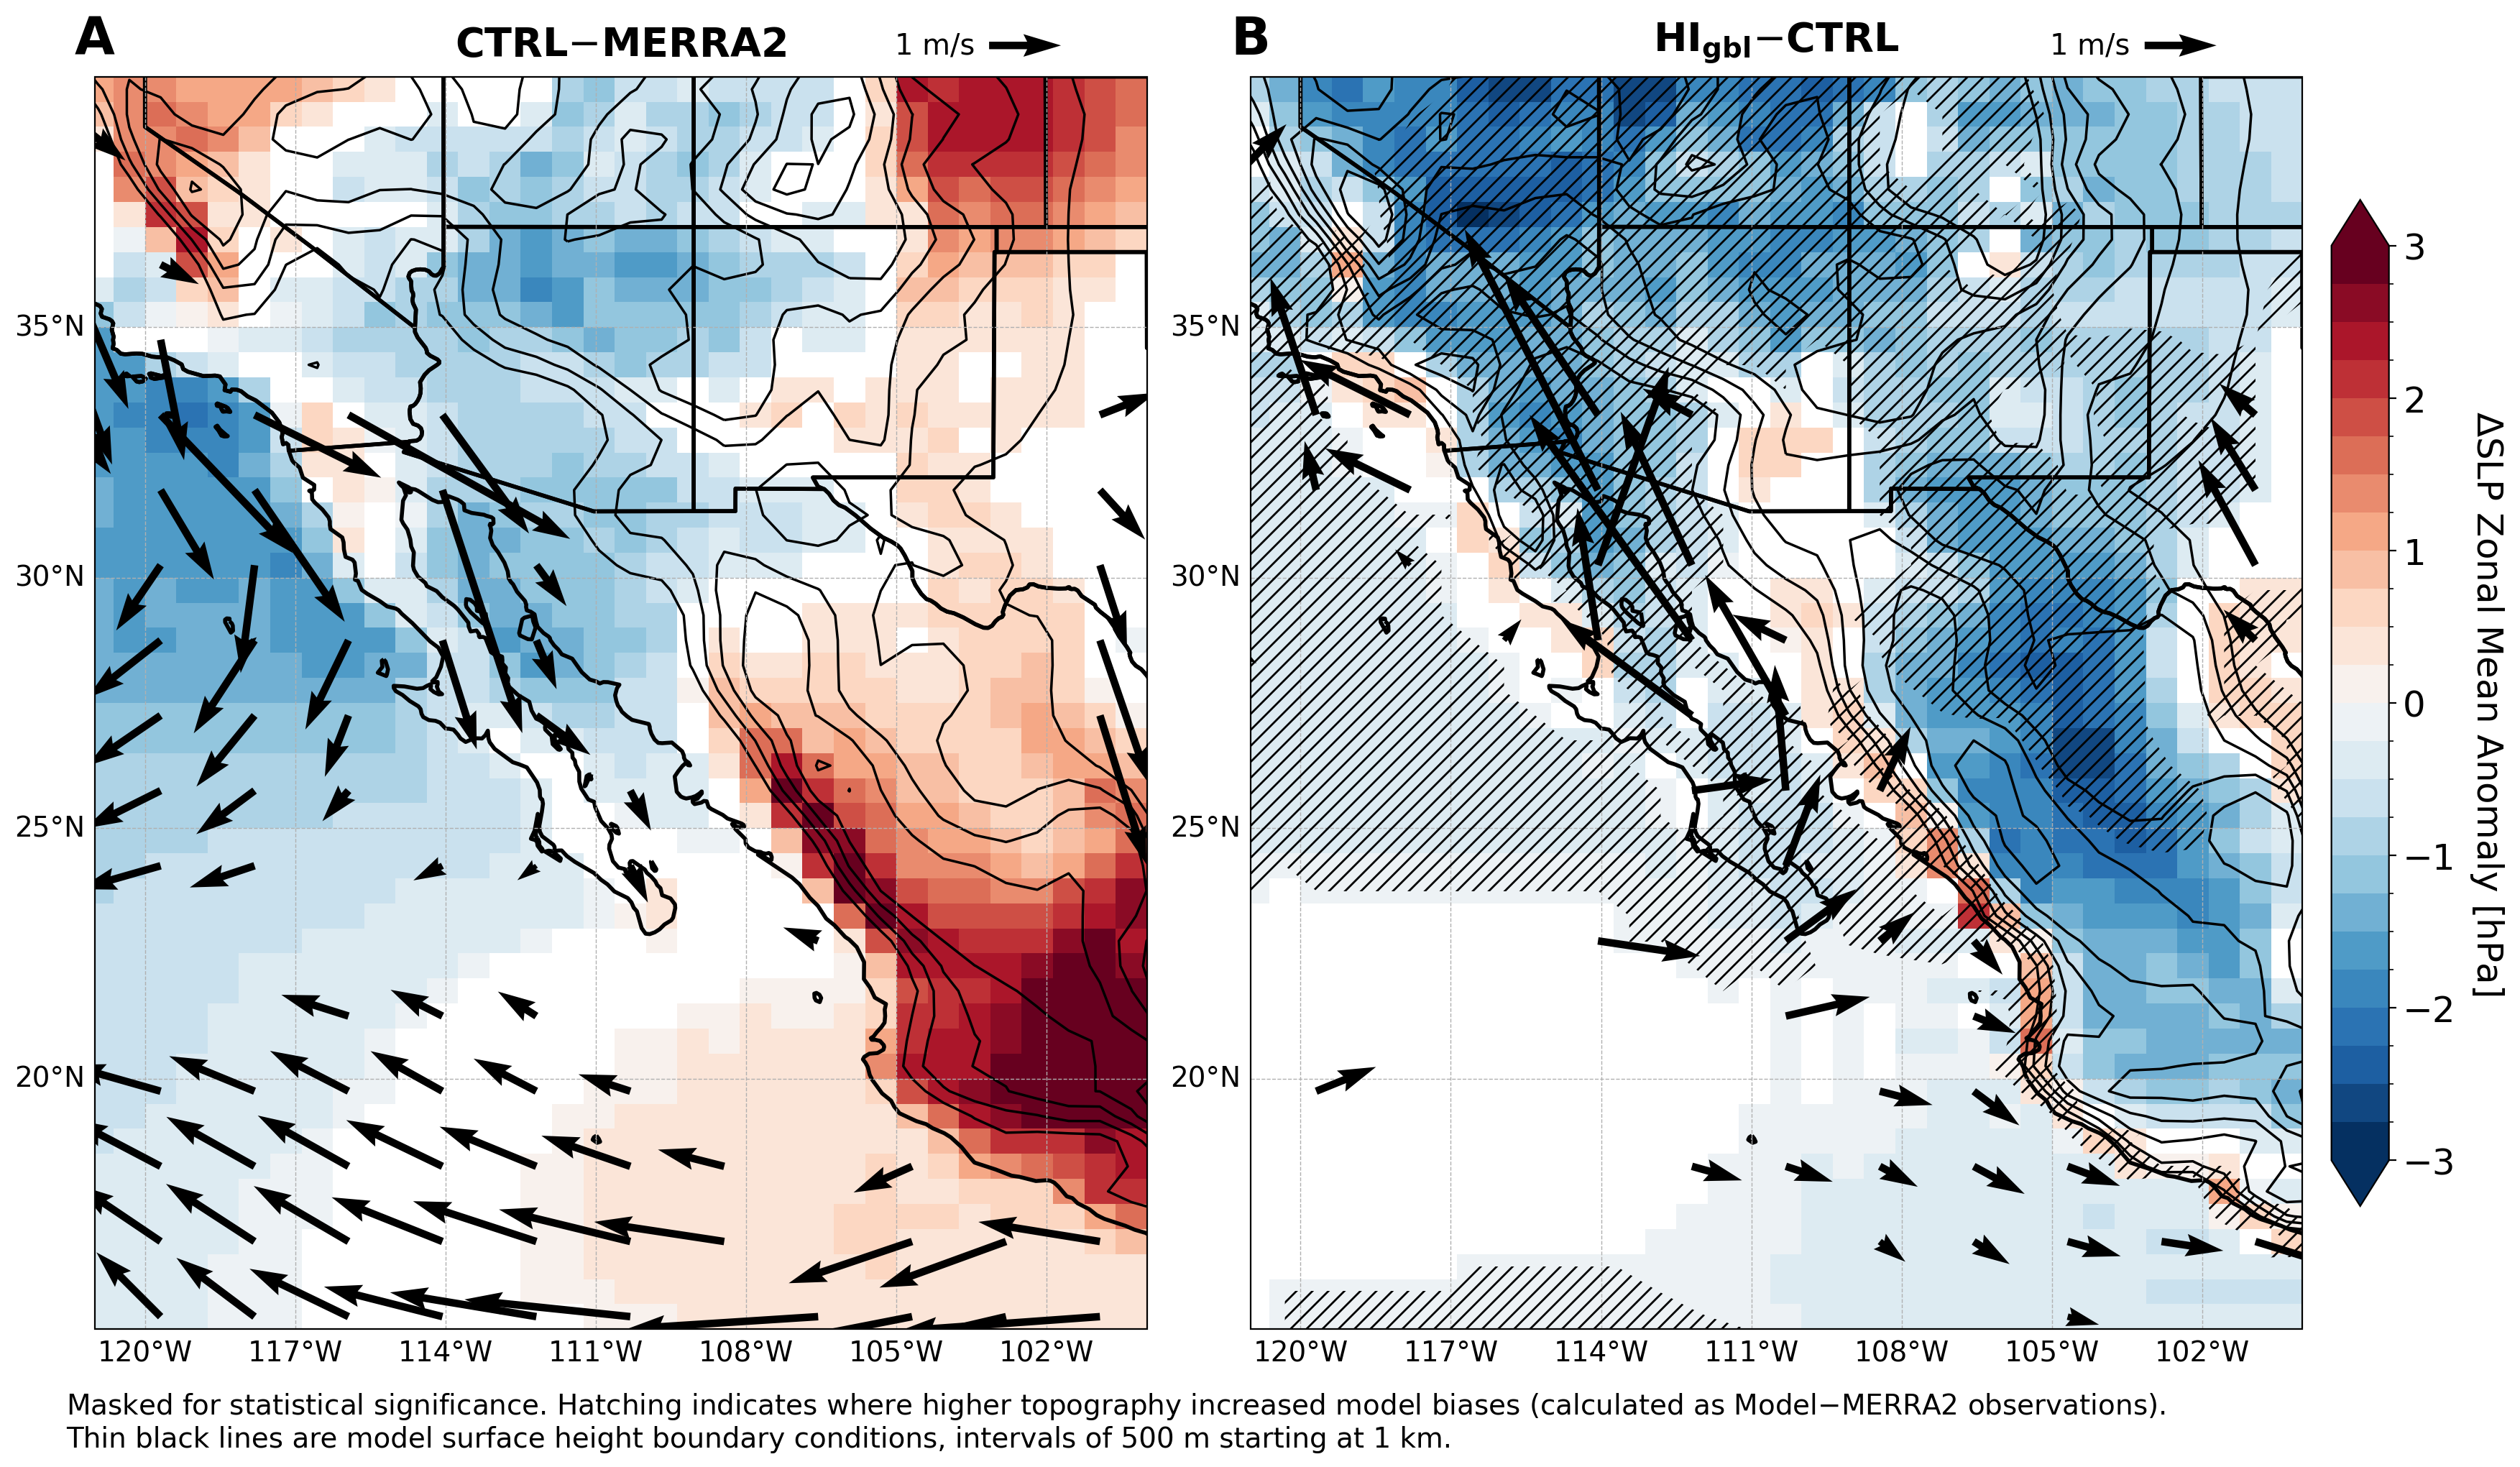

In [18]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array([r'CTRL$-$MERRA2', r'HI$_{\mathbf{gbl}}$$-$CTRL'])
letters=['A','B','C','D']
tx=-110.5
ty=40.25
# var specs
lat=jas_mean['flor']['ctrl']['h850'].lat
lon=jas_mean['flor']['ctrl']['h850'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=2
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='h850', diff=True)
dcmap=cm.RdBu_r
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,10), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Masked for statistical significance. Hatching indicates where higher topography increased model biases (calculated as Model$-$MERRA2 observations).\n'
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(lon, lat, obs_diff_mask['flor']['ctrl']['h850a'], cmap=dcmap, norm=dnorm, transform=trans)

# add wind vectors
q1=ax[0].quiver(lon[::skip_nh], lat[::skip_nh],
                obs_usig['flor']['ctrl'][::skip_nh,::skip_nh], obs_vsig['flor']['ctrl'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

#=== HI-GBL ===
ax[1].pcolormesh(lon, lat, model_diff_mask['flor']['hitopo']['h850a'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                model_usig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh], model_vsig['flor']['hitopo'].squeeze()[::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add hatching where bias got worse
ax[1].contourf(lon, lat, bias_change_masked['flor']['hitopo']['h850a'],
               0, colors='none', hatches=['','///'], extend='lower', zorder=100, transform=trans)
# add topo contours
ax[1].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-121, ty+0.5, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-10,10,21), orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$h850 Zonal Mean Anomaly [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/h850.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')

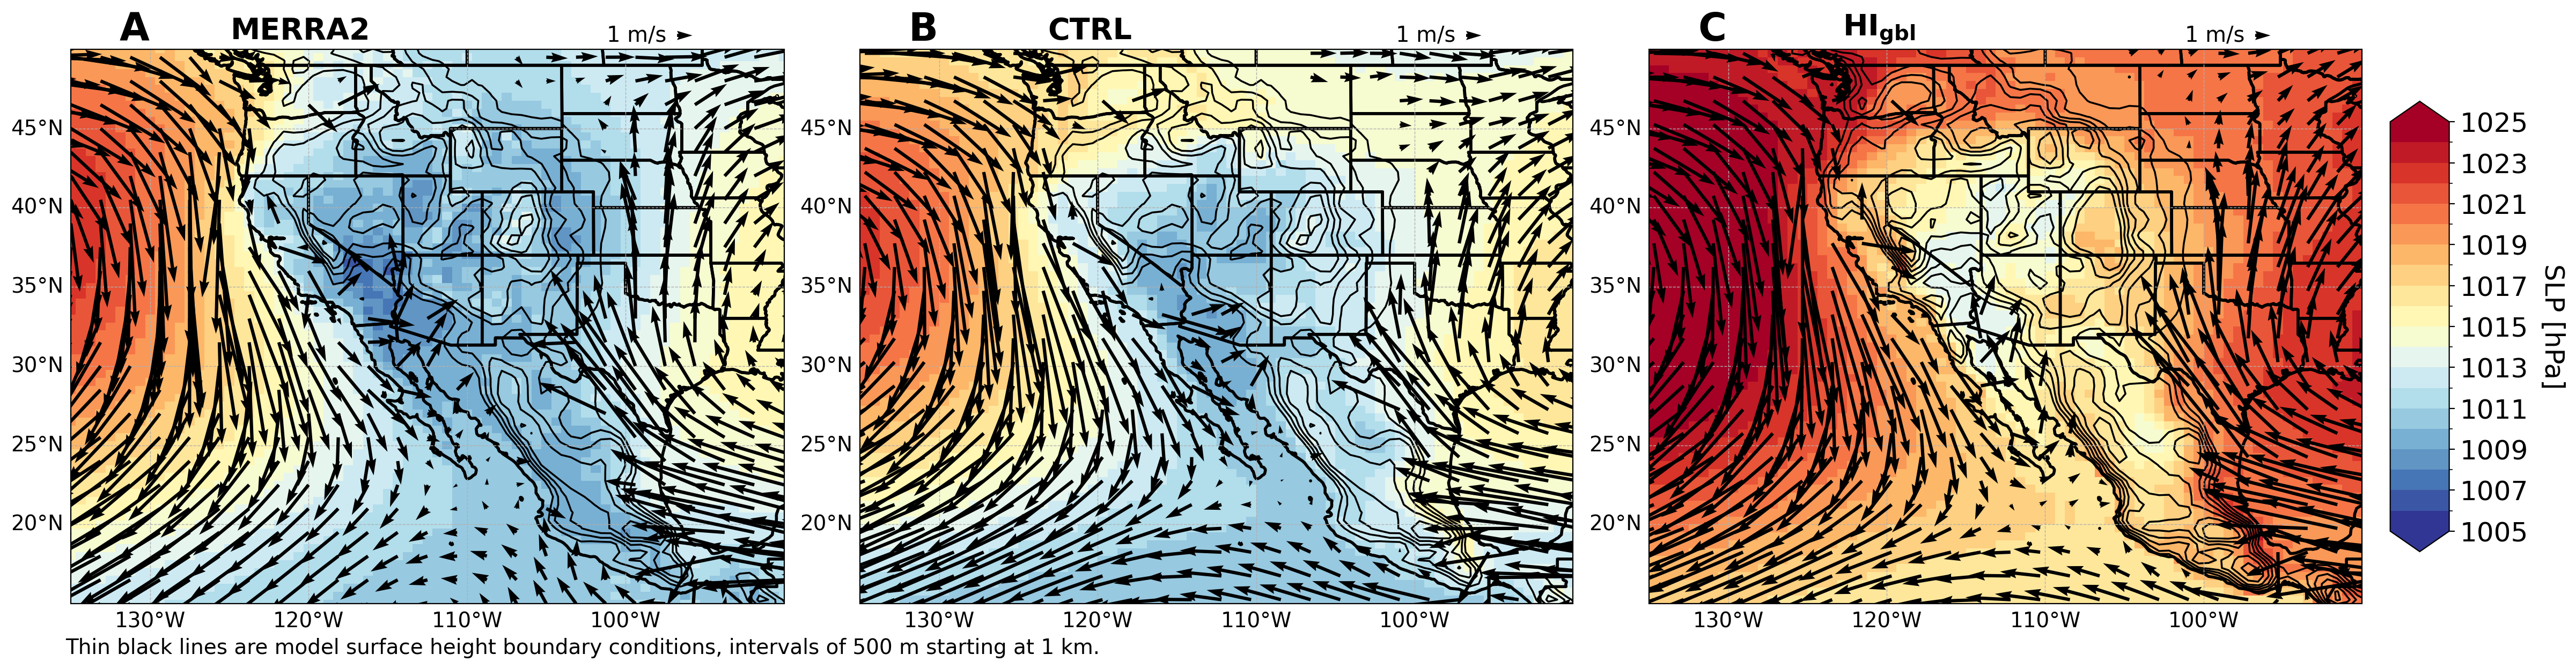

In [34]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C','D']
tx=-120.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['h850'].lat
lon=jas_mean['flor']['ctrl']['h850'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=7
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='h850', diff=True)
dcmap=cm.RdYlBu_r #RdBu_r
dvmin=1005
dvmax=1025
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['h850'].lon, jas_mean['obs']['merra2']['h850'].lat, jas_mean['obs']['merra2']['h850'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u850'].lon[::skip_nh], jas_mean['obs']['merra2']['u850'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u850'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['h850'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u850'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[1].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['h850'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u850'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-131, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(1005,1025,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('h850 [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') #Zonal Mean Anomaly 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/h850.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')

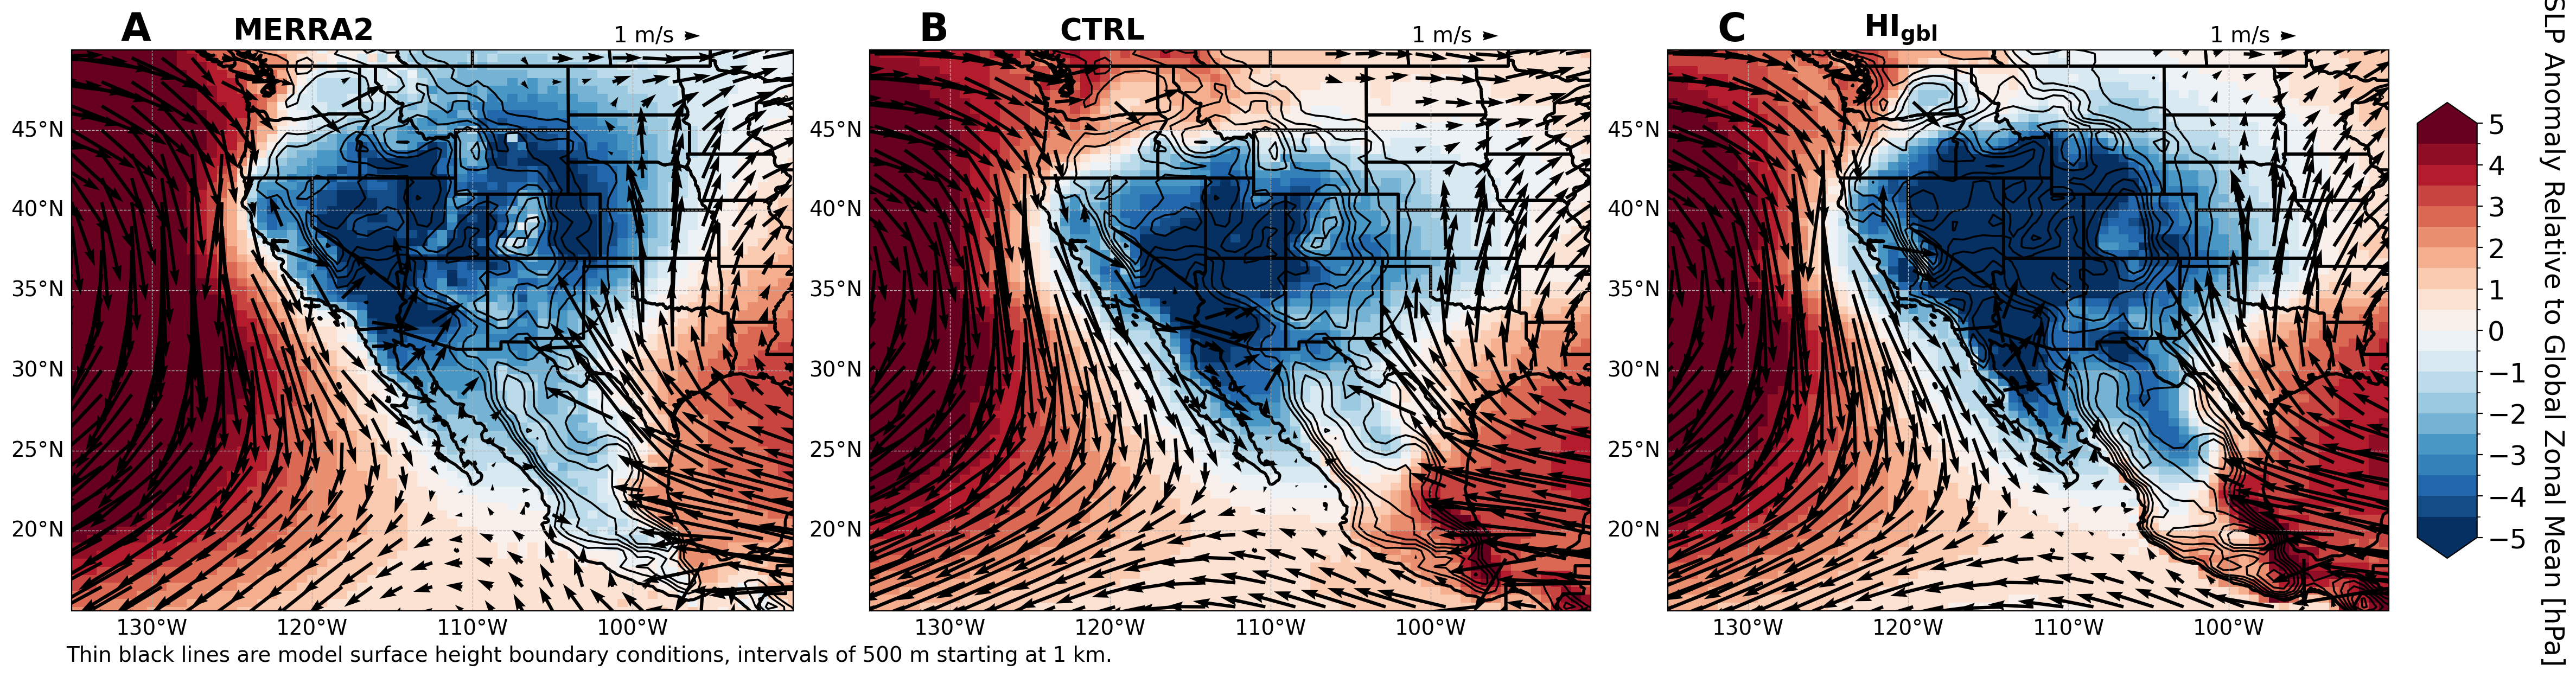

In [35]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':20, 'ha':'center', 'va':'bottom'}
text_kw2={'color':'k', 'weight':'bold', 'size':26, 'ha':'center', 'va':'center'}
text_kw3={'color':'k', 'weight':'normal', 'size':14, 'ha':'left', 'va':'center'}
titles=np.array(['MERRA2', 'CTRL', r'HI$_{\mathbf{gbl}}$'])
letters=['A','B','C','D']
tx=-120.5
ty=50.25
# var specs
lat=jas_mean['flor']['ctrl']['h850'].lat
lon=jas_mean['flor']['ctrl']['h850'].lon
# vector specs
skip_nh=3
skip_nl=1
w=0.006
scalef=7
key_length=1
# bias colormap
#dcmap,_,_,_=get_settings(field='h850', diff=True)
dcmap=cm.RdBu_r
dvmin=-5
dvmax=5
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,3000,7)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[225,270,15,50]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(22,6), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'Modified Topo $-$ CTRL', **text_kw)
fig.text(0.025,0,
         'Thin black lines are model surface height boundary conditions, intervals of 500 m starting at 1 km.',
         **text_kw3)

#=== CTRL ===
cf=ax[0].pcolormesh(jas_mean['obs']['merra2']['h850a'].lon, jas_mean['obs']['merra2']['h850a'].lat, jas_mean['obs']['merra2']['h850a'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[0].quiver(jas_mean['obs']['merra2']['u850'].lon[::skip_nh], jas_mean['obs']['merra2']['u850'].lat[::skip_nh],
                jas_mean['obs']['merra2']['u850'][::skip_nh,::skip_nh], jas_mean['obs']['merra2']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[0].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== CTRL ===
cf=ax[1].pcolormesh(lon, lat, jas_mean['flor']['ctrl']['h850a'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q1=ax[1].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['ctrl']['u850'][::skip_nh,::skip_nh], jas_mean['flor']['ctrl']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[1].quiverkey(q1, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[1].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)


#=== HI-GBL ===
ax[2].pcolormesh(lon, lat, jas_mean['flor']['hitopo']['h850a'], cmap=dcmap, norm=dnorm, transform=trans)
# add wind vectors
q2=ax[2].quiver(lon[::skip_nh], lat[::skip_nh],
                jas_mean['flor']['hitopo']['u850'][::skip_nh,::skip_nh], jas_mean['flor']['hitopo']['v850'][::skip_nh,::skip_nh],
                color='k', width=w, scale=scalef, scale_units='inches', units='height', transform=trans, zorder=100)
qk=ax[2].quiverkey(q2, .85, 1.025, key_length, rf'{key_length} m/s', labelcolor='k', labelpos='W', fontproperties={'size':'x-large'})
# add topo contours
ax[2].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1.25, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    # add box around core NAM domain
    lon_bnds = np.array([-113, -104, -104, -113])
    lat_bnds = np.array([20,  20,  34,  34])
    ring=LinearRing(list(zip(lon_bnds, lat_bnds)))
    #ax.add_geometries([ring], crs=trans, fc='none', ec='k', lw=3, linestyle='--', zorder=11) 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-131, ty+1, letters[i], **text_kw2)
    # map properties
    ax.coastlines(color='k', linewidth=2)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=2)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=2)
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':14}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':14}

# colorbar
cax=fig.add_axes([1.01, 0.15, 0.025, 0.7])
cbar=fig.colorbar(cf, ticks=np.linspace(-5,5,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('h850 Anomaly Relative to Global Zonal Mean [hPa]', labelpad=25, rotation=270, size=18, fontweight='normal', ha='center') #Zonal Mean Anomaly 
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/h850.flor.e3.nam-change.{season}.pdf', transparent=False, bbox_inches='tight')